# 09 · H1 — Cast-Adjusted Protagonist Homophily (intuitive figures)

**Question (H1):** Do female protagonists talk to their *own gender* less than male protagonists —
**after** accounting for the cast each protagonist is given?

**Sample:** N=17 (9 F-led + 8 M-led), UNIFIED conventions (Soul dropped; Monsters Inc = Sulley).
Source: `film_features_all_n17.csv`.

---
### How to read every figure in this notebook
- **`protag_samesex` (raw):** of the protagonist's dialogue, the share spoken to **same-gender** characters. 0 → 1.
- **`protag_samesex_z` (cast-adjusted):** how far that share sits from what the **cast alone** would predict, in standard deviations.
  - **z = 0** → exactly what the cast makes available (pure chance). *This is the meaningful reference, not 0/1.*
  - **z > 0** → talks to own gender **MORE** than chance (genuine leaning).
  - **z < 0** → talks to own gender **LESS** than chance.
- The thesis claim lives in the **contrast**: a big raw gap that **disappears** after cast adjustment ⇒ the raw gap was just cast composition.

In [1]:
from pathlib import Path
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CLEAN = Path('..').resolve()
sys.path.insert(0, str(CLEAN / 'analysis' / 'h1_homophily'))
from _common import (GENDER_PALETTE, GENDER_ORDER, RNG_SEED,
                     mannwhitney, cliffs_delta, perm_test_diff, bootstrap_diff_ci,
                     rank_biserial, set_style, power_note)
set_style()

DATA = CLEAN / 'data' / 'processed'
FIG  = CLEAN / 'analysis' / 'h1_homophily' / 'figures_n17'
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA / 'film_features_all_n17.csv')
print(f"N={len(df)}   F={(df.lead_gender=='F').sum()}   M={(df.lead_gender=='M').sum()}")
df[['film_title','protagonist','lead_gender','protag_samesex','protag_samesex_z','protag_samesex_p']]

N=17   F=9   M=8


,film_title,protagonist,lead_gender,protag_samesex,protag_samesex_z,protag_samesex_p
0,Beauty & the Beast (1991),Belle,F,0.2500,1.291,0.1274
1,Mulan (1998),Mulan,F,0.2000,-0.651,0.7486
2,Frozen (2013),Anna,F,0.2500,2.132,0.0140
3,Inside Out (2015),Joy,F,0.4286,-1.175,0.9290
4,Zootopia (2016),Hopps,F,0.2632,-1.480,0.9145
5,Incredibles 2 (2018),Elastigirl,F,0.4444,2.417,0.0160
6,Encanto (2021),Mirabel,F,0.5833,-0.098,0.9005
7,Raya (2021),Raya,F,0.4444,-1.493,0.9735
8,Elemental (2023),Ember,F,0.4286,1.808,0.1114
9,Toy Story (1995),Woody,M,0.8889,3.397,0.0055


## 1. H1 test — raw vs cast-adjusted (F vs M)

In [2]:
def hgroups(col):
    F = df[df.lead_gender=='F'][col].dropna().values
    M = df[df.lead_gender=='M'][col].dropna().values
    return F, M

def panel(col, label):
    F, M = hgroups(col)
    mw  = mannwhitney(F, M, 'two-sided')
    d   = cliffs_delta(F, M)
    ci  = bootstrap_diff_ci(F, M, stat=np.median)
    return {'measure':label, 'median_F':round(np.median(F),3), 'median_M':round(np.median(M),3),
            'Cliffs_delta':round(d,3), 'MW_p':round(mw['p'],4),
            'boot_CI_median_FminusM':f"[{ci['ci_lo']:.3f}, {ci['ci_hi']:.3f}]"}

res = pd.DataFrame([panel('protag_samesex','RAW same-gender share'),
                    panel('protag_samesex_z','CAST-ADJUSTED z')])
print(power_note((df.lead_gender=='F').sum(), (df.lead_gender=='M').sum()), "\n")
res

With n_F=9 and n_M=8, Mann-Whitney U has very limited power. Minimum two-sided p achievable is 7.6e-06 only when the groups are perfectly separated; detection of a 'medium' effect (Cliff's δ≈0.33) is below ~30% at α=0.05. 



,measure,median_F,median_M,Cliffs_delta,MW_p,boot_CI_median_FminusM
0,RAW same-gender share,0.429,0.733,-0.944,0.0003,"[-0.598, -0.154]"
1,CAST-ADJUSTED z,-0.098,0.300,-0.028,0.9626,"[-2.021, 2.425]"


## 2. Figure 1 — the decomposition (the headline figure)

**Left = RAW** (a big female-below-male gap). **Right = CAST-ADJUSTED** (the gap is gone).
This single contrast *is* the H1 result: the obvious raw gap is explained by cast composition.

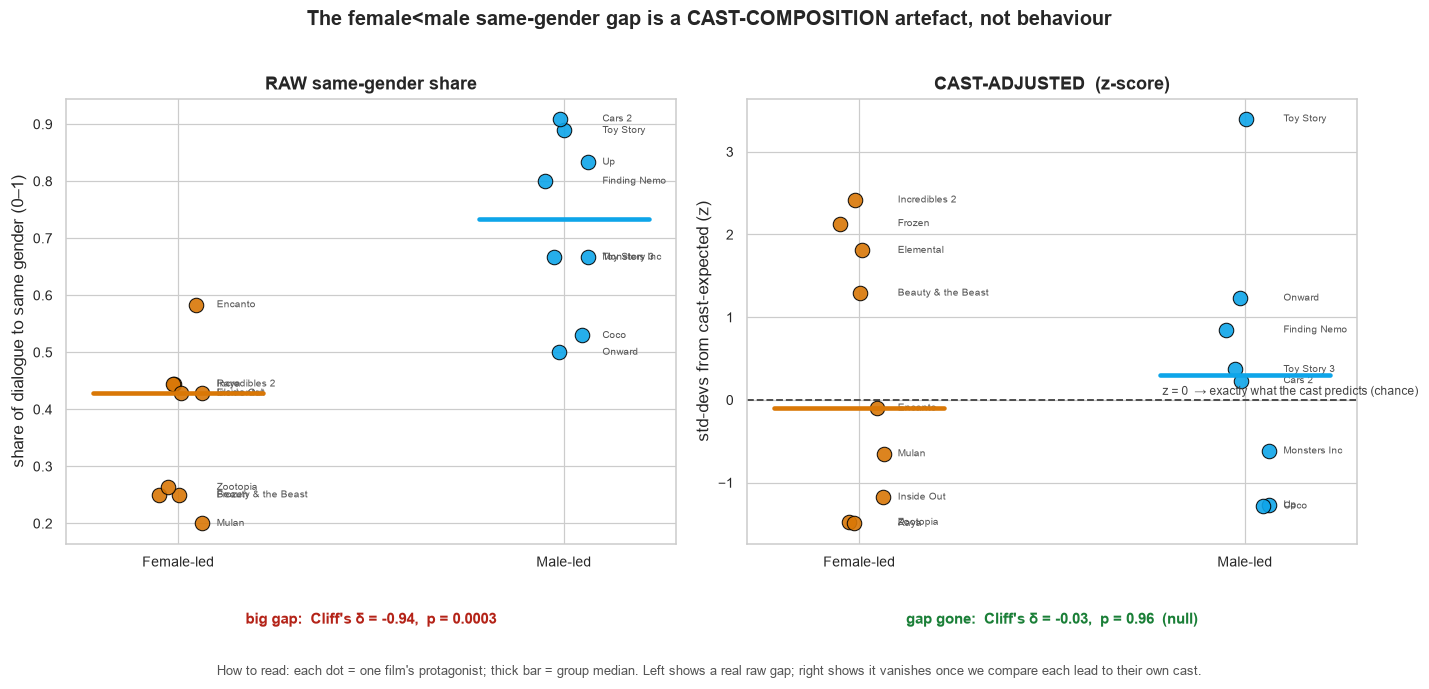

In [3]:
F_raw,M_raw   = hgroups('protag_samesex')
F_adj,M_adj   = hgroups('protag_samesex_z')
d_raw = cliffs_delta(F_raw,M_raw); p_raw = mannwhitney(F_raw,M_raw)['p']
d_adj = cliffs_delta(F_adj,M_adj); p_adj = mannwhitney(F_adj,M_adj)['p']

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2)); 
jit = {'F':-0.0,'M':0.0}
def strip(ax, col, title, ref0=False):
    for g in GENDER_ORDER:
        sub = df[df.lead_gender==g]
        x = np.full(len(sub), GENDER_ORDER.index(g)) + np.random.default_rng(1).uniform(-0.07,0.07,len(sub))
        ax.scatter(x, sub[col], s=90, color=GENDER_PALETTE[g], edgecolor='black', lw=.7, zorder=3, alpha=.9)
        med = sub[col].median()
        ax.plot([GENDER_ORDER.index(g)-0.22, GENDER_ORDER.index(g)+0.22],[med,med],
                color=GENDER_PALETTE[g], lw=3, zorder=4)
        for _,r in sub.iterrows():
            ax.annotate(r.film_title.split(' (')[0], (GENDER_ORDER.index(g)+0.10, r[col]),
                        fontsize=6.5, va='center', color='#555')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Female-led','Male-led']); ax.set_title(title)
    if ref0:
        ax.axhline(0, color='#444', lw=1.2, ls='--')
        ax.text(1.45, 0.06, 'z = 0  → exactly what the cast predicts (chance)', fontsize=8, color='#444', ha='right')
        ax.annotate('more same-gender\nthan chance', xy=(1.42,1.6), fontsize=8, color='#1a7f37', ha='right')
        ax.annotate('less same-gender\nthan chance', xy=(1.42,-1.6), fontsize=8, color='#b42318', ha='right')

strip(axes[0],'protag_samesex','RAW same-gender share')
axes[0].set_ylabel('share of dialogue to same gender (0–1)')
axes[0].text(0.5,-0.18,f"big gap:  Cliff's δ = {d_raw:+.2f},  p = {p_raw:.4f}",
             ha='center', fontsize=10, color='#b42318', weight='bold', transform=axes[0].get_xaxis_transform())
strip(axes[1],'protag_samesex_z','CAST-ADJUSTED  (z-score)', ref0=True)
axes[1].set_ylabel('std-devs from cast-expected (z)')
axes[1].text(0.5,-0.18,f"gap gone:  Cliff's δ = {d_adj:+.2f},  p = {p_adj:.2f}  (null)",
             ha='center', fontsize=10, color='#1a7f37', weight='bold', transform=axes[1].get_xaxis_transform())
fig.suptitle("The female<male same-gender gap is a CAST-COMPOSITION artefact, not behaviour",
             fontsize=13, weight='bold')
fig.text(0.5,0.005,"How to read: each dot = one film's protagonist; thick bar = group median. "
         "Left shows a real raw gap; right shows it vanishes once we compare each lead to their own cast.",
         ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.03,1,0.96])
fig.savefig(FIG/'fig_h1_v2_decomposition.png', dpi=150); fig.savefig(FIG/'fig_h1_v2_decomposition.pdf')
plt.show()

**How to read Figure 1.**
Each dot is one film's protagonist (orange = female-led, blue = male-led); the thick bar is the group median.

- **Left (RAW):** y = the share of the protagonist's dialogue spoken to **same-gender** characters (0–1). Female-led leads cluster low (median ≈ 0.43), male-led leads high (median ≈ 0.73) — a large, "significant" gap (Cliff's δ = −0.94, p = 0.0003). The naïve reading would be *"male leads talk to their own gender far more than female leads do."*
- **Right (CAST-ADJUSTED):** y = how far each protagonist's same-gender share sits from what **their own cast** would predict by chance, in standard deviations. The dashed line **z = 0 is the reference (not 0 or 1)**: z = 0 → exactly cast-expected; **z > 0 → leans toward own gender *more* than chance; z < 0 → *less*.** Both group medians now sit ≈ 0 and the two colours overlap — the gap is **gone** (δ = −0.03, p = 0.96, null).

**The contrast is the result.** The raw gap is not behaviour (women avoiding women / men preferring men); it is **cast composition** — male-led films simply contain more male characters. Comparing each lead against their own cast removes it. For example, *Mulan* is the lowest dot on the left (0.20), but her cast is ~90% male, so on the right she is only slightly below chance; *Up* and *Coco* are high on the left but drop **below** 0 once adjusted; only *Toy Story*'s Woody stays genuinely high.

## 3. Figure 2 — per-protagonist cast-adjusted z (who leans, who doesn't)

Each protagonist vs **their own** cast. **0 = chance.** Right = leans toward own gender; left = away.
Stars = individually significant (p < 0.05).

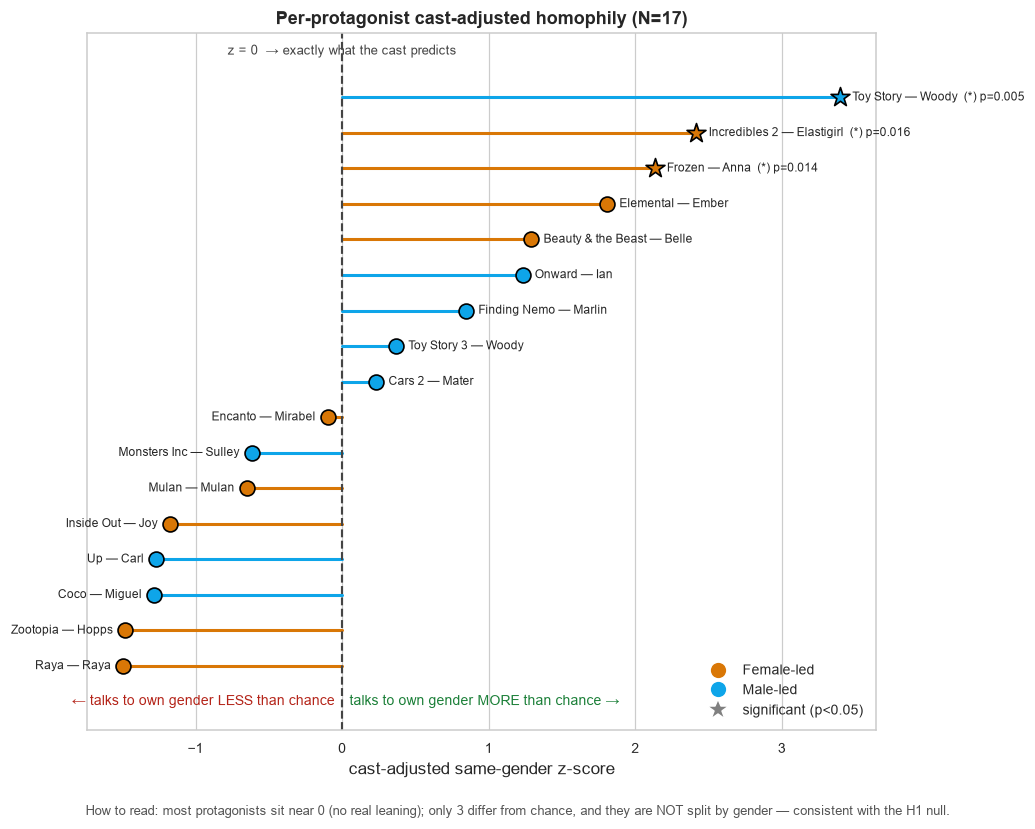

In [4]:
d = df.sort_values('protag_samesex_z').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9.5, 7.5))
for i,r in d.iterrows():
    col = GENDER_PALETTE[r.lead_gender]
    ax.plot([0, r.protag_samesex_z],[i,i], color=col, lw=2, zorder=2)
    sig = r.protag_samesex_p < 0.05
    ax.scatter(r.protag_samesex_z, i, s=170 if sig else 95, color=col,
               edgecolor='black', lw=1.1, marker='*' if sig else 'o', zorder=3)
    lbl = f"{r.film_title.split(' (')[0]} — {r.protagonist}"
    if sig: lbl += f"  (*) p={r.protag_samesex_p:.3f}"
    ax.annotate(lbl, (r.protag_samesex_z, i),
                xytext=(8 if r.protag_samesex_z>=0 else -8, 0), textcoords='offset points',
                ha='left' if r.protag_samesex_z>=0 else 'right', va='center', fontsize=8)
ax.axvline(0, color='#444', lw=1.4, ls='--')
ax.text(0, len(d)+0.2, 'z = 0  → exactly what the cast predicts', ha='center', fontsize=8.5, color='#444')
ax.annotate('← talks to own gender LESS than chance', xy=(-0.05,-1.1), xycoords=('data','data'),
            fontsize=9, color='#b42318', ha='right')
ax.annotate('talks to own gender MORE than chance →', xy=(0.05,-1.1), xycoords=('data','data'),
            fontsize=9, color='#1a7f37', ha='left')
ax.set_yticks([]); ax.set_xlabel('cast-adjusted same-gender z-score')
ax.set_ylim(-1.8, len(d)+0.8)
ax.set_title('Per-protagonist cast-adjusted homophily (N=17)')
leg = [Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='Female-led'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='Male-led'),
       Line2D([0],[0],marker='*',color='w',markerfacecolor='grey',markersize=15,label='significant (p<0.05)')]
ax.legend(handles=leg, loc='lower right', fontsize=9)
fig.text(0.5,0.005,"How to read: most protagonists sit near 0 (no real leaning); only 3 differ from chance, "
         "and they are NOT split by gender — consistent with the H1 null.", ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.03,1,1])
fig.savefig(FIG/'fig_h1_v2_lollipop.png', dpi=150); fig.savefig(FIG/'fig_h1_v2_lollipop.pdf')
plt.show()

**How to read Figure 2.**
One row per protagonist, sorted by the cast-adjusted z (the same measure as Figure 1's right panel, shown per film). Orange = female-led, blue = male-led. The dashed line **z = 0 = exactly what the cast predicts (chance)**; **right of 0 = talks to own gender *more* than chance, left of 0 = *less*.** Distance from 0 = how far the protagonist departs from chance.

- **Stars** mark the **3 individually significant** protagonists (p < 0.05): Woody (M, +3.4), Elastigirl (F, +2.4), Anna (F, +2.1). These are the only genuine leanings; the other **14 sit within noise of 0** — their same-gender share is explained by their cast.
- **Key H1 check:** if female leads were less same-gender embedded, all orange dots would sit on the left and all blue on the right. Instead the colours are **interleaved top to bottom — no gender separation**, consistent with the H1 null.
- Note that **2 of the 3 genuine leaners are female** (Anna, Elastigirl), both leaning *toward* their own gender — which cuts against a "women avoid women" reading.

## 4. Robustness — does the network-construction method change the H1 picture?

The cast-adjusted same-gender z computed **two ways**: the **ADDRESSEE** network (LLM "who talks to whom") vs the **CO-OCCURRENCE** network (two characters linked if they share a scene). If the two methods give the same answer, points fall on the **diagonal**.

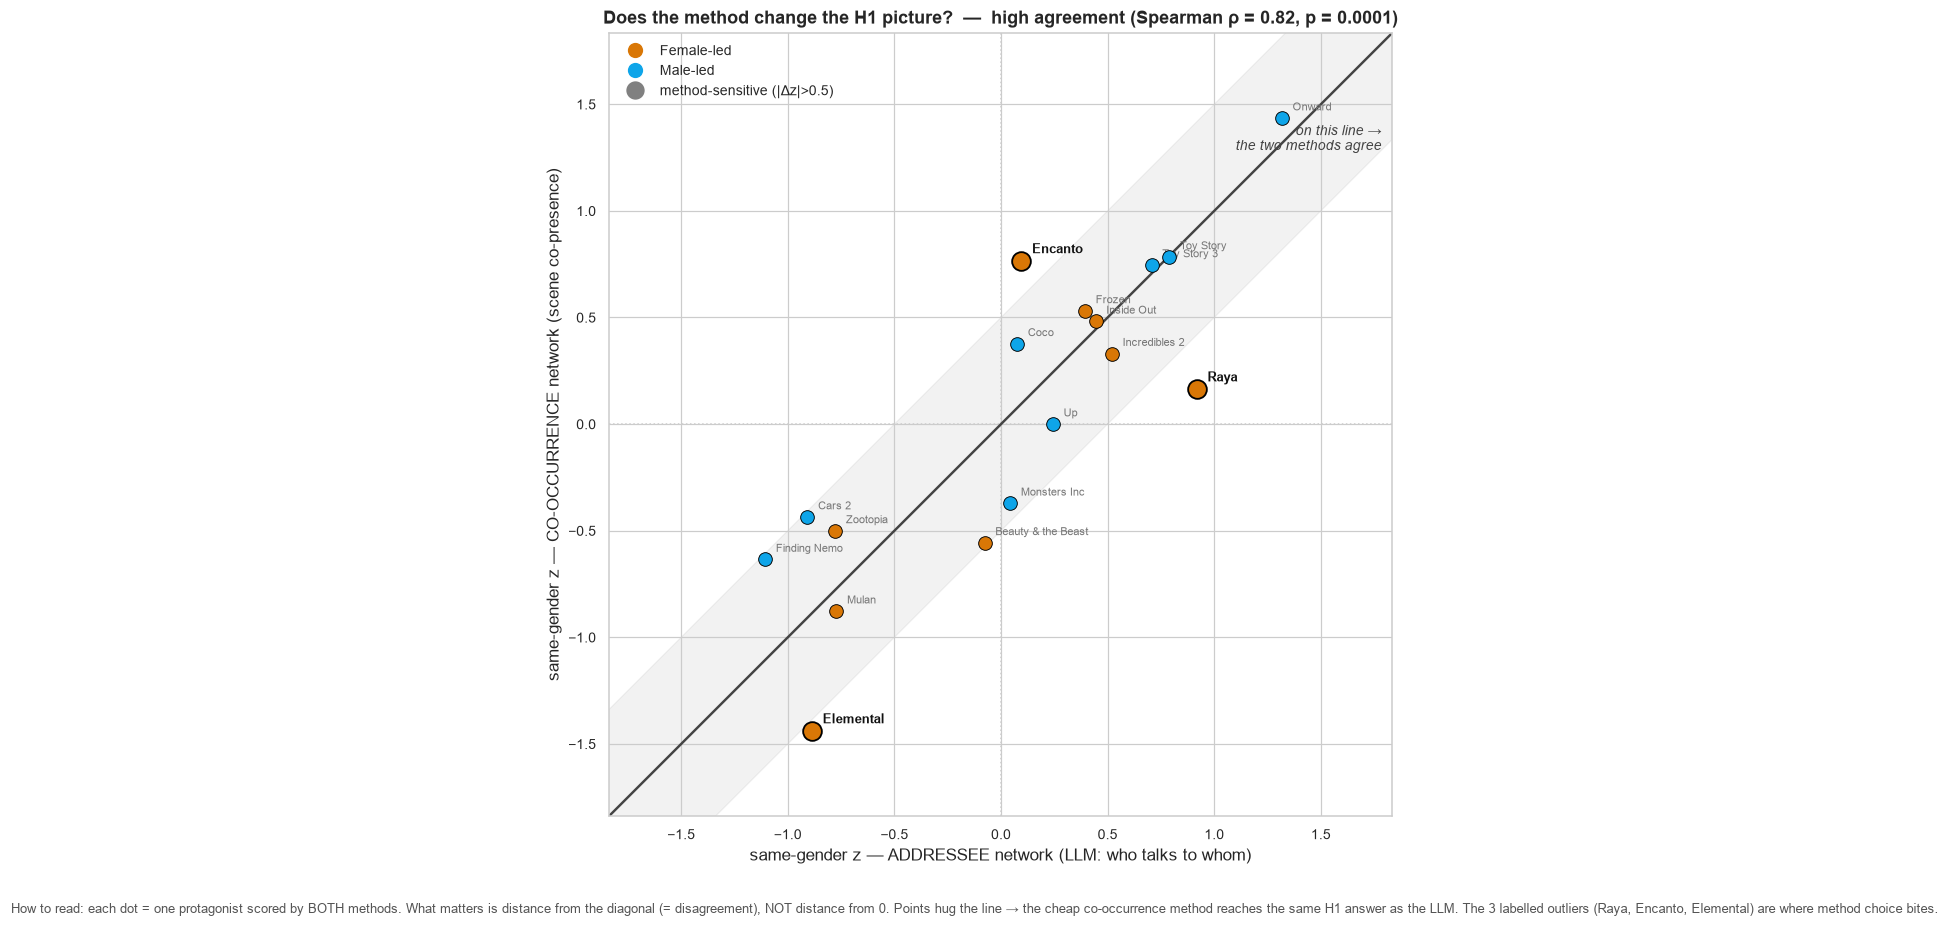

In [5]:
from scipy.stats import spearmanr
TBL = CLEAN / 'analysis' / 'h1_homophily' / 'tables_n17'
m = pd.read_csv(TBL / 'step2a_per_protag_method_compare.csv')
rho, prho = spearmanr(m.addr_samesex_z, m.cooc_samesex_z)

vals = np.concatenate([m.addr_samesex_z.values, m.cooc_samesex_z.values])
lim = [vals.min()-0.4, vals.max()+0.4]
xs = np.array(lim)

fig, ax = plt.subplots(figsize=(8.6, 8.4))
# agreement band (±0.5 around y=x) + diagonal
ax.fill_between(xs, xs-0.5, xs+0.5, color='grey', alpha=0.10, zorder=0)
ax.plot(xs, xs, color='#444', lw=1.6, zorder=1)
ax.axhline(0, color='#ccc', lw=1, ls=':', zorder=0); ax.axvline(0, color='#ccc', lw=1, ls=':', zorder=0)

for _, r in m.iterrows():
    col = GENDER_PALETTE[r.lead_gender]; far = r.abs_diff_z > 0.5
    ax.scatter(r.addr_samesex_z, r.cooc_samesex_z, s=150 if far else 80,
               color=col, edgecolor='black', lw=1.2 if far else .6, zorder=3)
    ax.annotate(r.film_title.split(' (')[0], (r.addr_samesex_z, r.cooc_samesex_z),
                xytext=(7,5), textcoords='offset points',
                fontsize=8.5 if far else 7, weight='bold' if far else 'normal',
                color='#111' if far else '#777')
ax.text(lim[1]-0.05, lim[1]-0.55, 'on this line →\nthe two methods agree',
        fontsize=9, color='#444', ha='right', style='italic')
ax.set_xlabel('same-gender z — ADDRESSEE network (LLM: who talks to whom)')
ax.set_ylabel('same-gender z — CO-OCCURRENCE network (scene co-presence)')
ax.set_title(f'Does the method change the H1 picture?  —  high agreement (Spearman ρ = {rho:.2f}, p = {prho:.4f})')
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='Female-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='Male-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='grey',markersize=13,label='method-sensitive (|Δz|>0.5)')],
    loc='upper left', fontsize=9)
fig.text(0.5, 0.005,
    "How to read: each dot = one protagonist scored by BOTH methods. What matters is distance from the "
    "diagonal (= disagreement), NOT distance from 0. Points hug the line → the cheap co-occurrence method "
    "reaches the same H1 answer as the LLM. The 3 labelled outliers (Raya, Encanto, Elemental) are where method choice bites.",
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.04,1,1])
fig.savefig(FIG/'fig_h1_v2_method_scatter.png', dpi=150); fig.savefig(FIG/'fig_h1_v2_method_scatter.pdf')
plt.show()

**How to read Figure 3.**
Each dot is one protagonist's cast-adjusted same-gender z, computed **twice** — x = the LLM addressee network, y = the scene co-occurrence network. The **diagonal is the reference, not 0 or 1**: a point **on the diagonal means the two ways of building the network give the same answer**; distance **from the diagonal** (the shaded band is ±0.5) measures how much the method choice changes the result.

- Points **hug the diagonal** and the rank-agreement is high (**Spearman ρ = 0.82**) → for the **aggregate H1 test**, the cheap co-occurrence pipeline reaches the **same** conclusion as the expensive LLM one. This is why §3.10 of the write-up says co-occurrence is "sufficient" for the population-level gender test.
- The **3 labelled outliers** (Raya, Encanto, Elemental) sit furthest from the line — these are the per-film cases where "who actually talks to whom" diverges from "who merely shares scenes."

> This figure shows the methods **agree** on H1. The place where the LLM is **not** replaceable is **keystone identity** (the structural-role question) — that is a separate Pillar-B figure (the keystone gender-flip in female-led films), not shown here.

## 5. Figure 4 — Keystone identity: where the LLM is *not* replaceable

The **keystone** is the highest-betweenness non-protagonist — the supporting character whose removal most fragments the network (Moretti's Horatio test). **Which** character that is can depend on how the network is built. This is the place the cheap co-occurrence pipeline and the LLM addressee pipeline disagree in a **gendered** way.

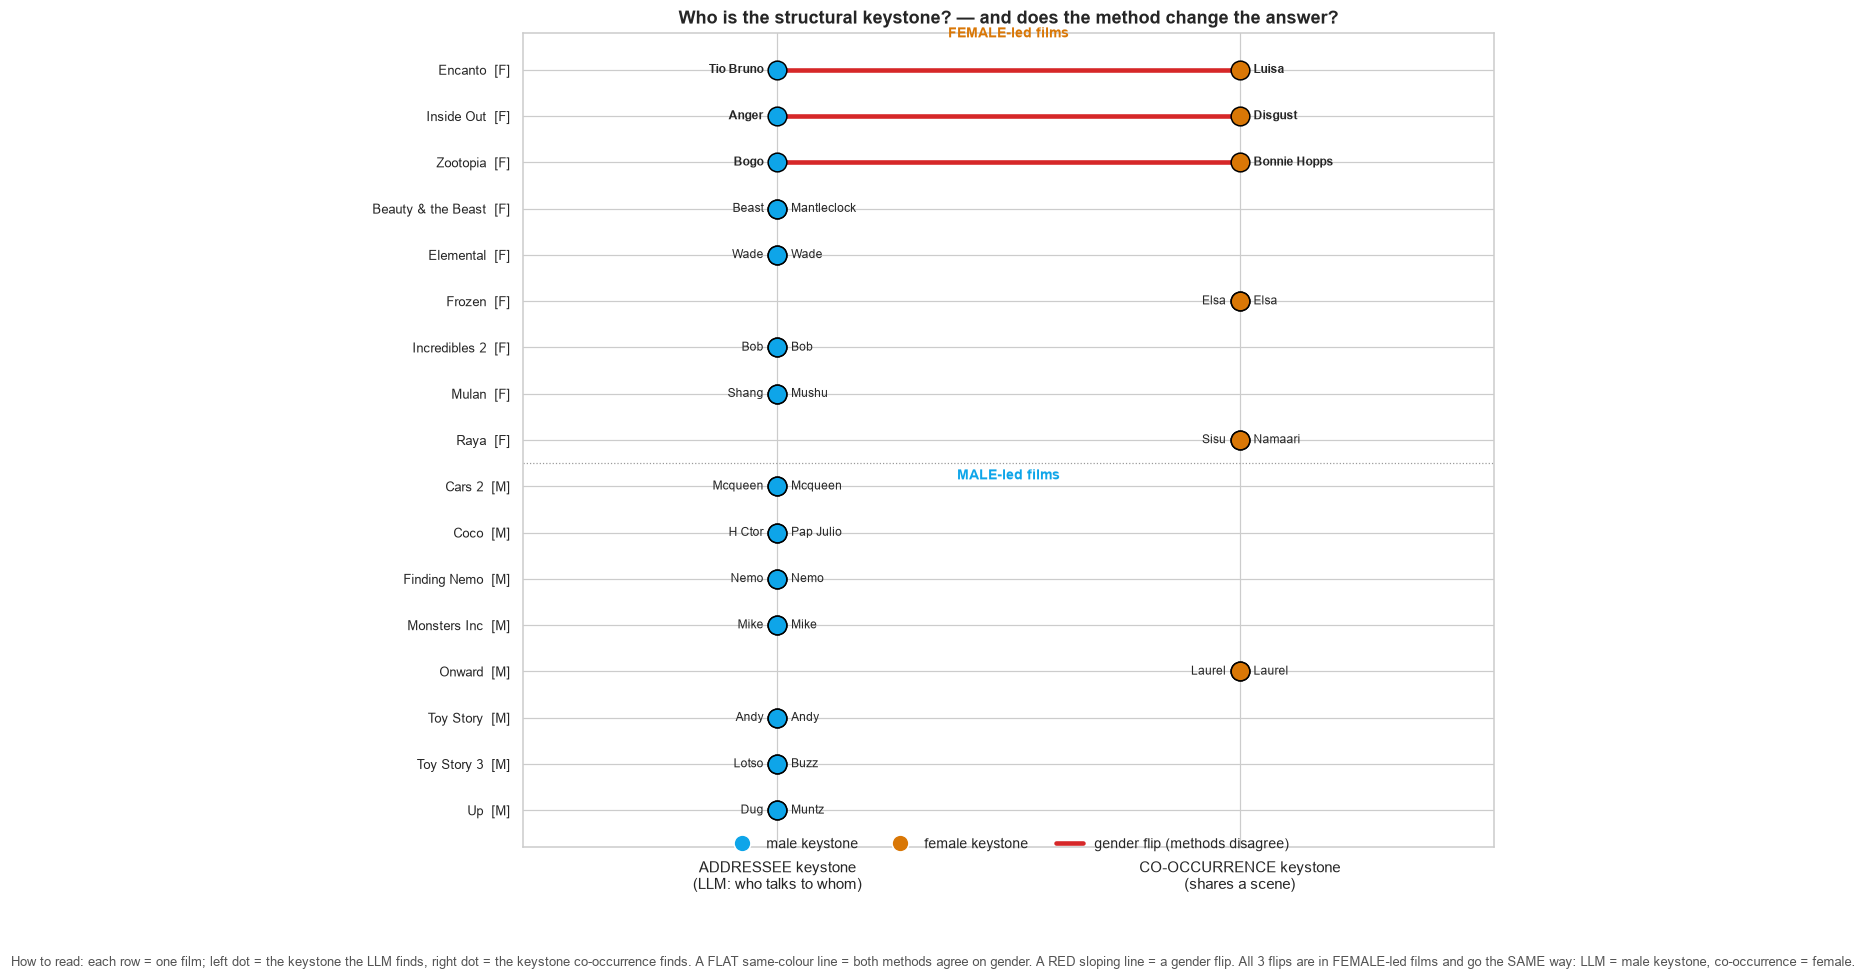

flips:        film_title keystone_addr keystone_addr_gender keystone_cooc keystone_cooc_gender
   Encanto (2021)     Tio Bruno                    M         Luisa                    F
Inside Out (2015)         Anger                    M       Disgust                    F
  Zootopia (2016)          Bogo                    M  Bonnie Hopps                    F


In [6]:
k = pd.read_csv(TBL / 'step2f_keystone_agreement.csv')
# order: F-led on top (flips grouped first), then M-led
k['gf'] = k['gender_flip'].astype(int)
k = k.sort_values(['lead_gender','gf','film_title'], ascending=[True, False, True]).reset_index(drop=True)
k['y'] = np.arange(len(k))[::-1]                      # first row at top
GPOS = {'M': 0.0, 'F': 1.0}

fig, ax = plt.subplots(figsize=(10.5, 8.5))
for _, r in k.iterrows():
    xa, xc = GPOS[r.keystone_addr_gender], GPOS[r.keystone_cooc_gender]
    flip = bool(r.gender_flip)
    ax.plot([xa, xc], [r.y, r.y], color='#d62728' if flip else '#bbb',
            lw=3 if flip else 1.2, alpha=1 if flip else .5, zorder=2)
    ax.scatter(xa, r.y, s=150, color=GENDER_PALETTE[r.keystone_addr_gender], edgecolor='black', lw=1, zorder=3)
    ax.scatter(xc, r.y, s=150, color=GENDER_PALETTE[r.keystone_cooc_gender], edgecolor='black', lw=1, zorder=3)
    ax.annotate(r.keystone_addr, (xa, r.y), xytext=(-9,0), textcoords='offset points',
                ha='right', va='center', fontsize=8, weight='bold' if flip else 'normal')
    ax.annotate(r.keystone_cooc, (xc, r.y), xytext=(9,0), textcoords='offset points',
                ha='left', va='center', fontsize=8, weight='bold' if flip else 'normal')
# divider between F-led and M-led blocks
n_f = (k.lead_gender=='F').sum()
ax.axhline(len(k)-n_f-0.5, color='#999', lw=0.8, ls=':')
ax.text(0.5, len(k)-0.3, 'FEMALE-led films', ha='center', fontsize=9, color='#D97706', weight='bold')
ax.text(0.5, len(k)-n_f-0.85, 'MALE-led films', ha='center', fontsize=9, color='#0EA5E9', weight='bold')

ax.set_xlim(-0.55, 1.55); ax.set_xticks([0,1])
ax.set_xticklabels(['ADDRESSEE keystone\n(LLM: who talks to whom)','CO-OCCURRENCE keystone\n(shares a scene)'], fontsize=10)
ax.set_yticks(k.y); ax.set_yticklabels([f"{t.split(' (')[0]}  [{g}]" for t,g in zip(k.film_title,k.lead_gender)], fontsize=8.5)
ax.set_title('Who is the structural keystone? — and does the method change the answer?')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='male keystone'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='female keystone'),
    Line2D([0],[0],color='#d62728',lw=3,label='gender flip (methods disagree)')],
    loc='lower center', bbox_to_anchor=(0.5,-0.02), ncol=3, fontsize=9)
fig.text(0.5, -0.04,
    "How to read: each row = one film; left dot = the keystone the LLM finds, right dot = the keystone "
    "co-occurrence finds. A FLAT same-colour line = both methods agree on gender. A RED sloping line = a "
    "gender flip. All 3 flips are in FEMALE-led films and go the SAME way: LLM = male keystone, co-occurrence = female.",
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.02,1,1])
fig.savefig(FIG/'fig_h1_v2_keystone_flip.png', dpi=150); fig.savefig(FIG/'fig_h1_v2_keystone_flip.pdf')
plt.show()

print("flips:", k[k.gender_flip][['film_title','keystone_addr','keystone_addr_gender','keystone_cooc','keystone_cooc_gender']].to_string(index=False))

**How to read Figure 4.**
Each row is one film. The **left dot** is the keystone the **LLM addressee** network identifies; the **right dot** is the keystone the **co-occurrence** network identifies. Dot colour = that keystone's gender (orange = female, blue = male). A **flat, same-colour line** means the two methods agree on the keystone's gender; a **red sloping line** is a **gender flip**.

- The two methods agree on the keystone character in only **8/17** films, but the disagreements are **not random**: all **3 gender flips are in female-led films**, and all go the **same direction** — the **LLM finds a male keystone where co-occurrence sees a female one** (*Inside Out*: Anger vs Disgust; *Zootopia*: Bogo vs Bonnie Hopps; *Encanto*: Tío Bruno vs Luisa).
- **Why:** co-occurrence credits a tie whenever two characters share a scene, so female alters who merely co-appear with the female lead in ensemble/household scenes get inflated betweenness and are promoted to keystone. The LLM tracks who the lead **actually addresses**, which in these films falls on a male bridging character.
- **Consequence:** with the cheap co-occurrence pipeline, the count of female-led films "structurally held up by a male non-lead" would drop from **7/9 to 4/9**. This structural-role finding exists **only** under addressee tagging — this is where the LLM step earns its cost.

> **Human validation:** the three authors watched these three films and, by consensus, judged the keystone to be the **addressee (LLM)** character in all three — Bruno (*Encanto*), Bogo (*Zootopia*), and Anger (*Inside Out*) — not the co-occurrence one (Luisa, Bonnie Hopps, Disgust). The structural-role advantage of addressee tagging is therefore confirmed against human judgment, not merely argued.

## 6. Verdict

- **Raw:** female protagonists' same-gender share is far below male protagonists' (large δ, tiny p).
- **Cast-adjusted:** the gap **disappears** (δ≈0, p≈0.96). Both genders sit ≈ where their cast predicts.
- Only **3/17** protagonists differ from chance individually (Anna, Elastigirl, Woody) — and they don't form a gender pattern.

**H1 is not supported once cast composition is accounted for.** The headline raw gap is a cast-composition artefact — which *is* the methodological contribution.

> Figures: `analysis/h1_homophily/figures_n17/fig_h1_v2_decomposition.*`, `fig_h1_v2_lollipop.*`.
> Note: the "addressee z vs co-occurrence z" method-comparison figure (Majo's other pain point) belongs to **Pillar B** — it will be redesigned in the method-comparison notebook, not here.